In [1]:
# general
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
# for data
import os
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms

GEN_NOISE_DIM = 50
GEN_OUT_DIM = 28 * 28 * 1
NUM_EPOCHS = 50

In [2]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            # upsample 50 to 128
            nn.Linear(GEN_NOISE_DIM, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.25),
            # upsample 128 to 256
            nn.Linear(128, 256), 
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.25),
            # upsample 256 to 512
            nn.Linear(256, 512), 
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.25),
            # final upsample 512 to 784 + out 
            nn.Linear(512, GEN_OUT_DIM),
            nn.Tanh()
        )
    def forward(self, x):
        return self.layers(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            # downsample
            nn.Linear(GEN_OUT_DIM, 1024),
            nn.LeakyReLU(0.25),
            # downsample
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.25),
            # downsample
            nn.Linear(512, 256),
            nn.LeakyReLU(0.25),
            # final downsample + binary out
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

In [3]:
def get_train_loader(batch_size: int = 128):
    dataset = MNIST(
        os.getcwd(),
        download=True,
        train=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,),(0.5,)) # normalize between -1, 1 bc Generator uses tanh which gives those
        ])
    )
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return train_loader


Epoch #0
generator loss: 0.6442412734031677
discriminator loss: 0.7585683600045741


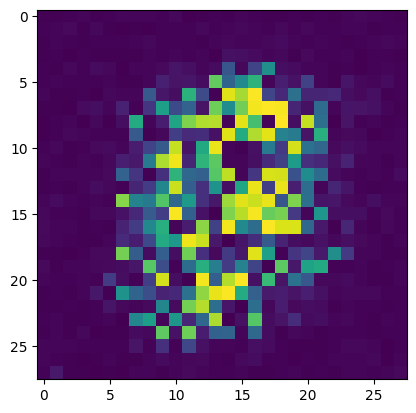

discr guess: 0.5021701455116272

Epoch #1
generator loss: 0.6818768382072449
discriminator loss: 0.7307848231866956


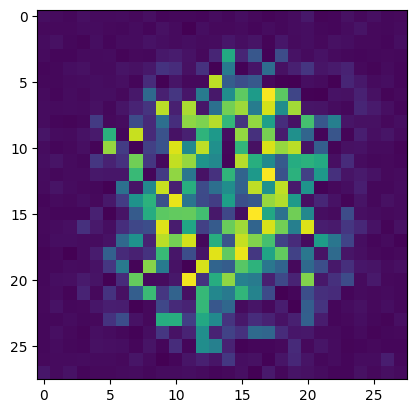

discr guess: 0.47260573506355286

Epoch #2
generator loss: 0.6498731374740601
discriminator loss: 0.7700552521273494


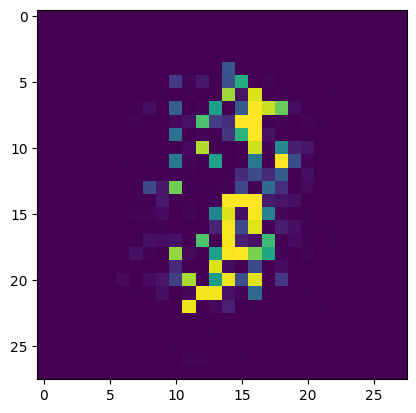

discr guess: 0.5201148390769958

Epoch #3
generator loss: 0.6826491355895996
discriminator loss: 0.823936777189374


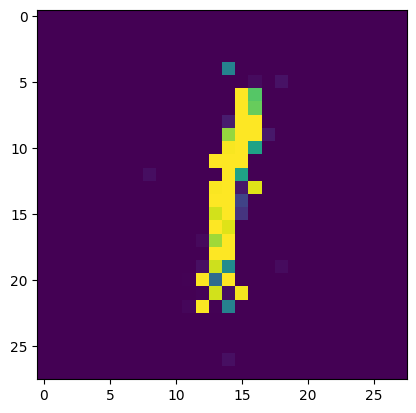

discr guess: 0.5265359282493591

Epoch #4
generator loss: 0.7053282856941223
discriminator loss: 0.7179108448326588


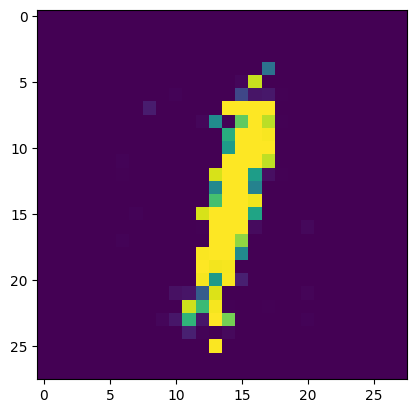

discr guess: 0.4989326298236847

Epoch #5
generator loss: 0.7108566164970398
discriminator loss: 0.8583182245492935


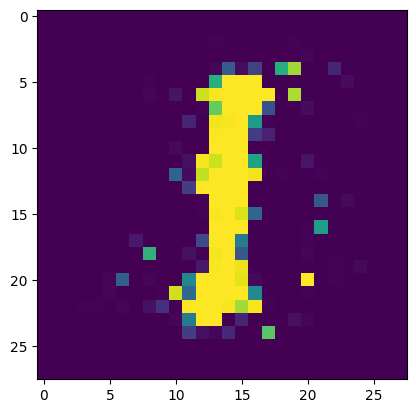

discr guess: 0.4785788059234619

Epoch #6
generator loss: 0.6195028424263
discriminator loss: 0.8268040344119072


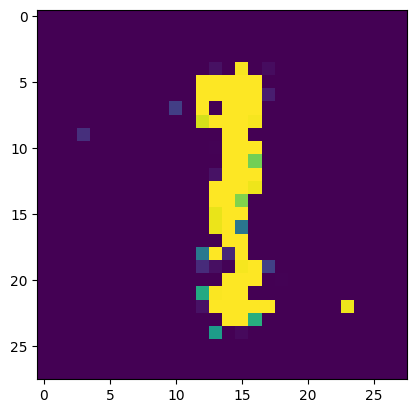

discr guess: 0.5395208597183228

Epoch #7
generator loss: 0.6569229364395142
discriminator loss: 0.8083634153008461


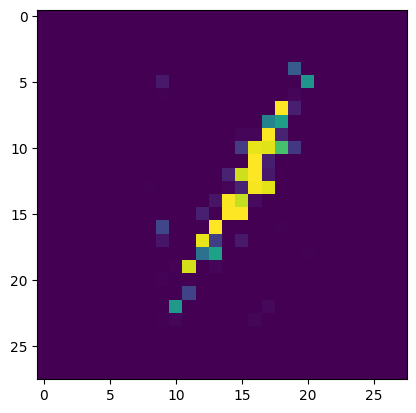

discr guess: 0.4809652864933014

Epoch #8
generator loss: 0.557548999786377
discriminator loss: 1.0191377401351929


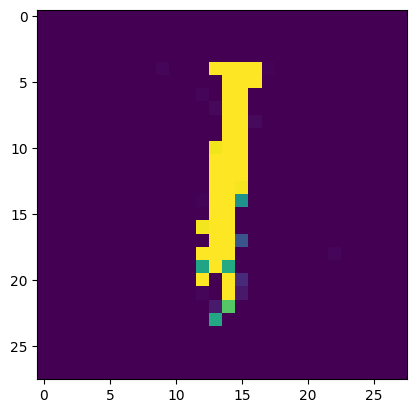

discr guess: 0.6114521026611328

Epoch #9
generator loss: 0.6140183806419373
discriminator loss: 0.914619654417038


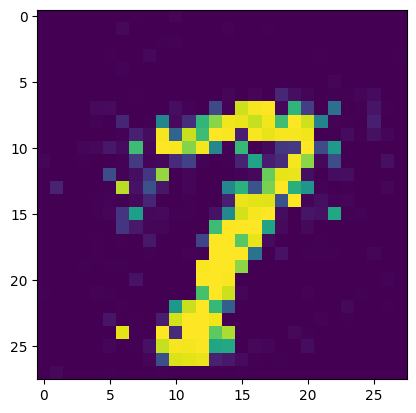

discr guess: 0.5654634833335876

Epoch #11
generator loss: 0.5282206535339355
discriminator loss: 0.9460672959685326


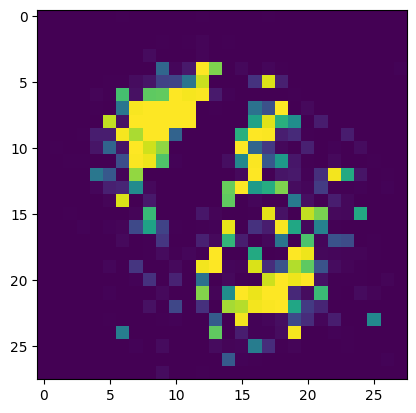

discr guess: 0.5254285335540771

Epoch #12
generator loss: 0.6085097193717957
discriminator loss: 0.8815133571624756


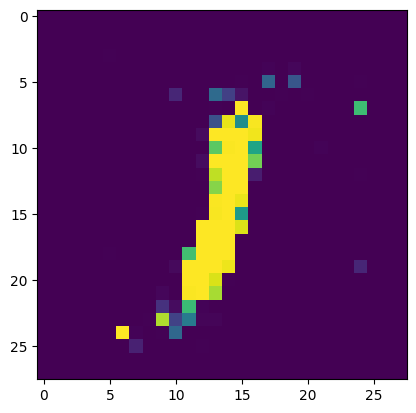

discr guess: 0.5909020900726318

Epoch #13
generator loss: 0.6344851851463318
discriminator loss: 0.973304495215416


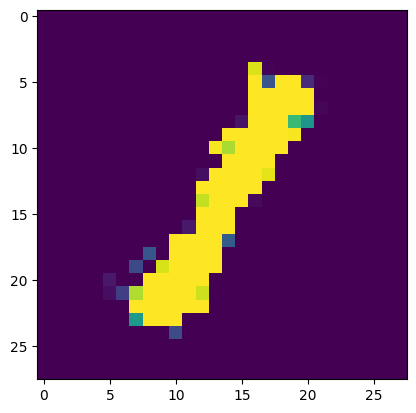

discr guess: 0.5599565505981445

Epoch #14
generator loss: 0.6682742238044739
discriminator loss: 0.8667466193437576


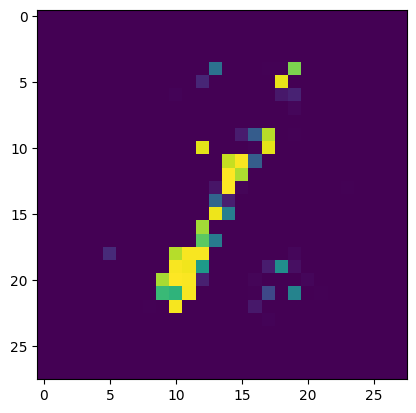

discr guess: 0.5629017353057861

Epoch #15
generator loss: 0.5650080442428589
discriminator loss: 1.0388288721442223


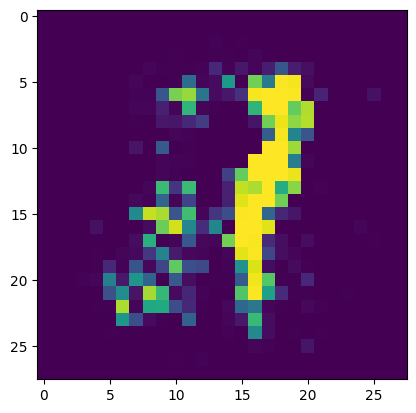

discr guess: 0.6245086193084717

Epoch #16
generator loss: 0.4478396475315094
discriminator loss: 1.2479391992092133


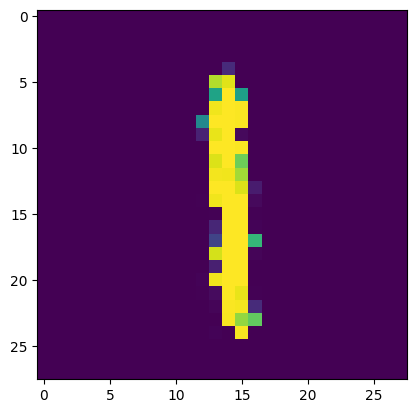

discr guess: 0.6631948351860046

Epoch #17
generator loss: 0.7064132690429688
discriminator loss: 1.1000950932502747


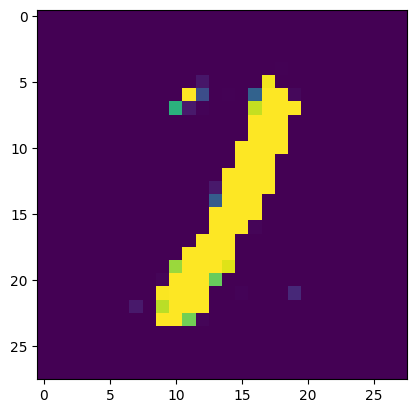

discr guess: 0.5334794521331787

Epoch #18
generator loss: 0.6074017882347107
discriminator loss: 0.9357474148273468


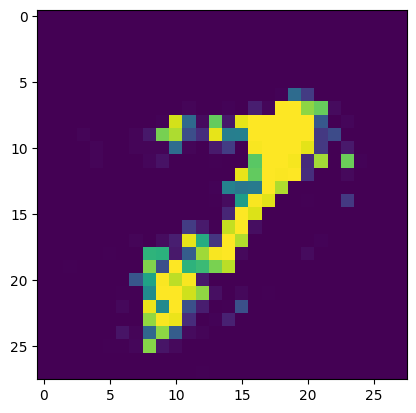

discr guess: 0.5226442813873291

Epoch #19
generator loss: 0.6650775074958801
discriminator loss: 1.0430940687656403


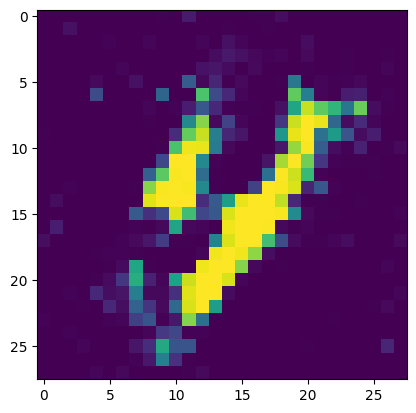

discr guess: 0.5856149792671204

Epoch #21
generator loss: 0.6455219388008118
discriminator loss: 1.0173808261752129


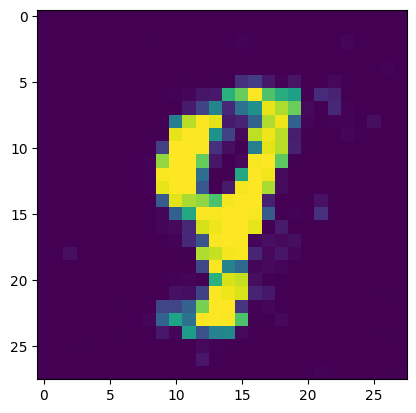

discr guess: 0.5662906169891357

Epoch #22
generator loss: 0.4108283519744873
discriminator loss: 1.185386911034584


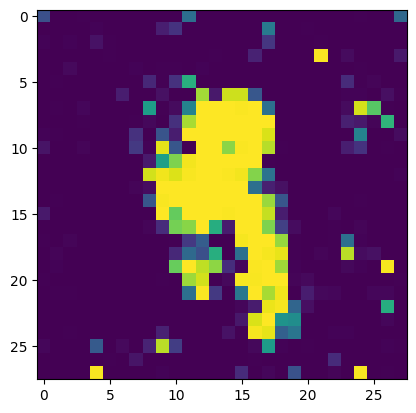

discr guess: 0.6532002687454224

Epoch #23
generator loss: 0.5437123775482178
discriminator loss: 1.0219667851924896


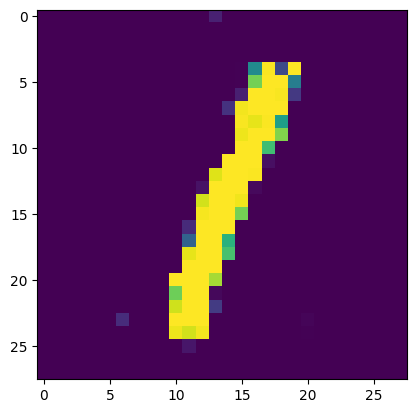

discr guess: 0.6366869807243347

Epoch #24
generator loss: 0.5284700989723206
discriminator loss: 1.0496831685304642


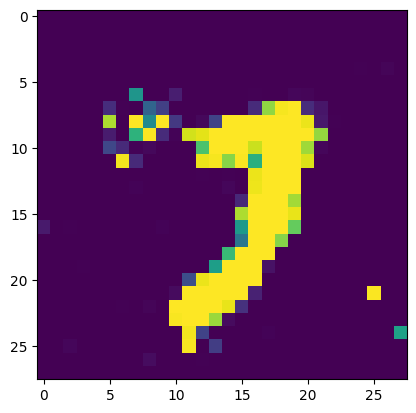

discr guess: 0.7237217426300049

Epoch #25
generator loss: 0.5034179091453552
discriminator loss: 1.1062157303094864


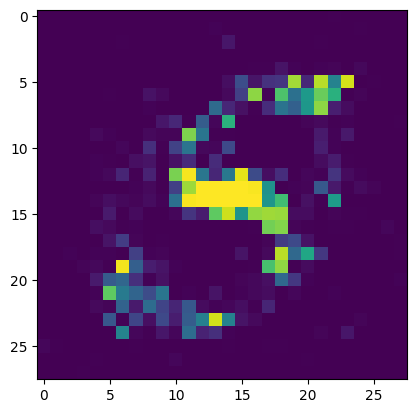

discr guess: 0.40947309136390686

Epoch #26
generator loss: 0.5327364802360535
discriminator loss: 1.0583343356847763


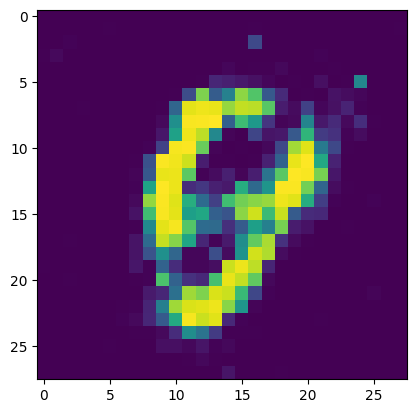

discr guess: 0.49793490767478943

Epoch #27
generator loss: 0.5832836031913757
discriminator loss: 1.1571416854858398


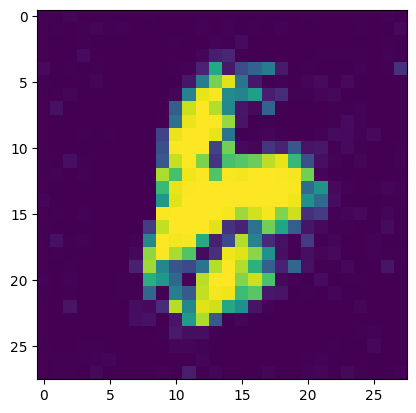

discr guess: 0.629923403263092

Epoch #28
generator loss: 0.5843842029571533
discriminator loss: 1.0084707885980606


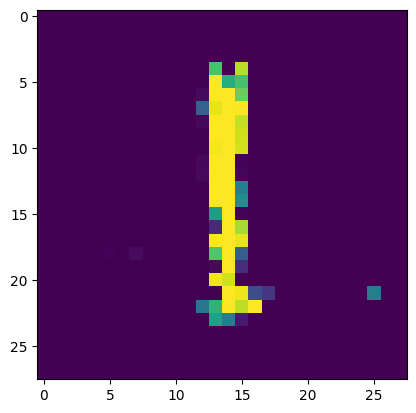

discr guess: 0.7330184578895569

Epoch #29
generator loss: 0.6314660310745239
discriminator loss: 1.0775581896305084


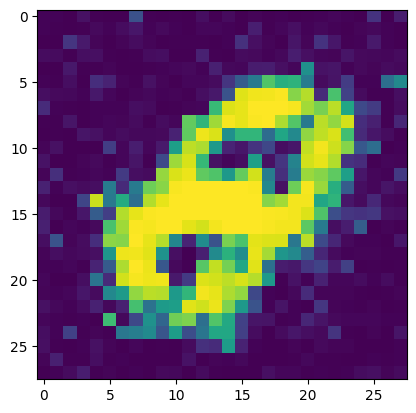

discr guess: 0.525082528591156

Epoch #31
generator loss: 0.4166414737701416
discriminator loss: 1.1248210668563843


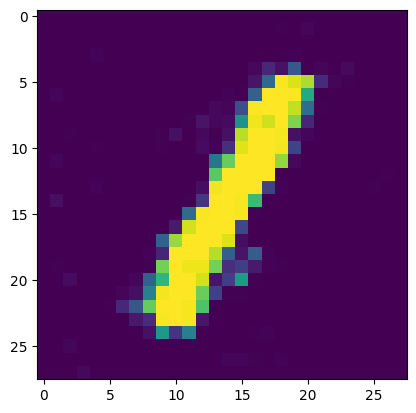

discr guess: 0.6407071352005005

Epoch #32
generator loss: 0.5344638228416443
discriminator loss: 1.076333537697792


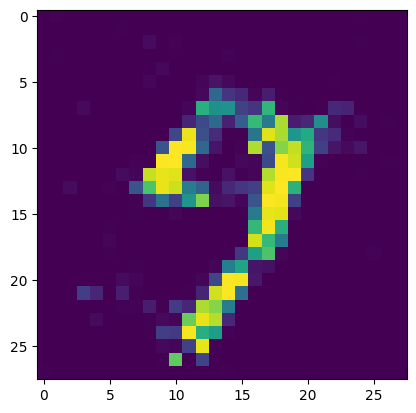

discr guess: 0.6764116883277893

Epoch #33
generator loss: 0.5490862727165222
discriminator loss: 1.0916326642036438


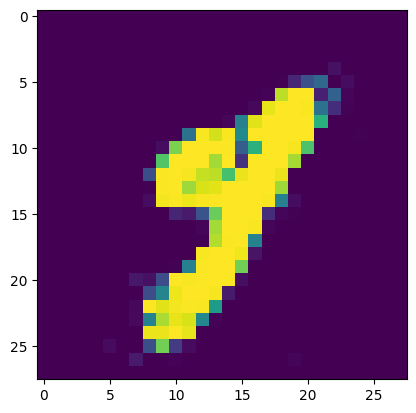

discr guess: 0.5853133797645569

Epoch #34
generator loss: 0.49107280373573303
discriminator loss: 1.036579355597496


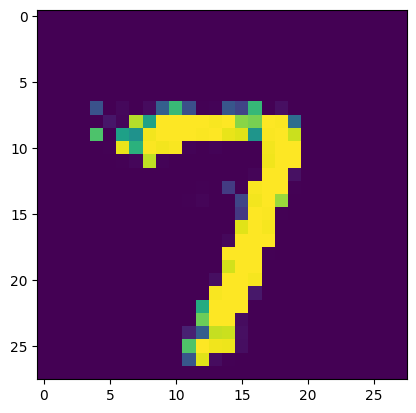

discr guess: 0.5459436774253845

Epoch #35
generator loss: 0.6016247868537903
discriminator loss: 1.1584991067647934


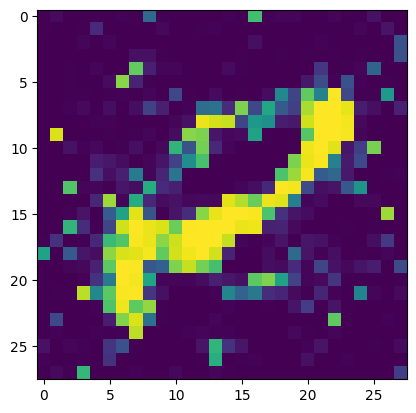

discr guess: 0.4769843816757202

Epoch #36
generator loss: 0.5271711349487305
discriminator loss: 1.0724116414785385


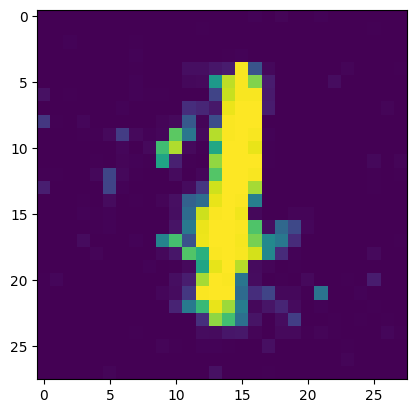

discr guess: 0.5783572196960449

Epoch #37
generator loss: 0.5197855830192566
discriminator loss: 1.0934531837701797


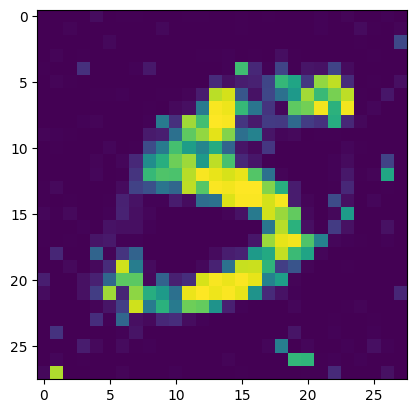

discr guess: 0.5880779027938843

Epoch #38
generator loss: 0.4800703823566437
discriminator loss: 1.209415227174759


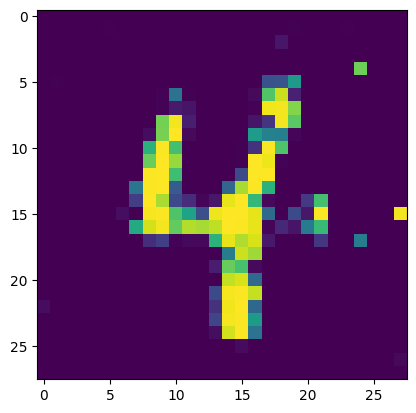

discr guess: 0.5213704705238342

Epoch #39
generator loss: 0.5731735825538635
discriminator loss: 1.0070426762104034


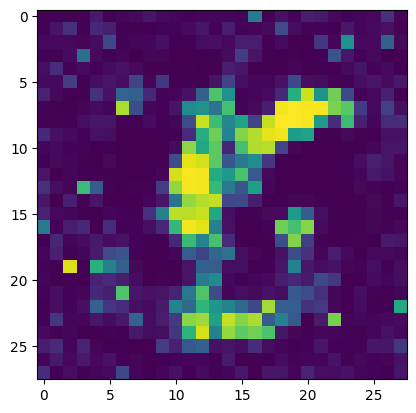

discr guess: 0.6046703457832336

Epoch #41
generator loss: 0.6040841937065125
discriminator loss: 1.1481480300426483


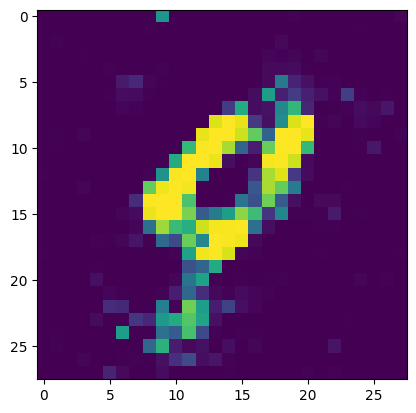

discr guess: 0.45441195368766785

Epoch #42
generator loss: 0.5417369604110718
discriminator loss: 1.1877990365028381


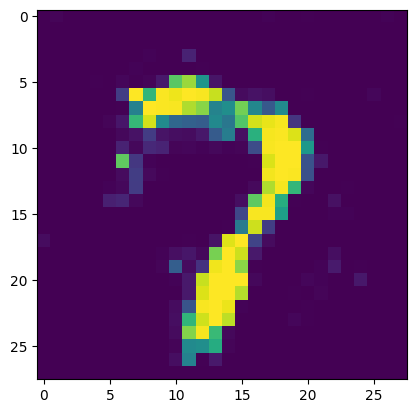

discr guess: 0.6130698323249817

Epoch #43
generator loss: 0.6947527527809143
discriminator loss: 1.21613048017025


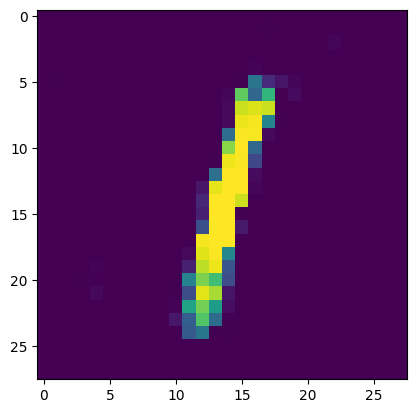

discr guess: 0.5723974108695984

Epoch #44
generator loss: 0.676478385925293
discriminator loss: 1.14414082467556


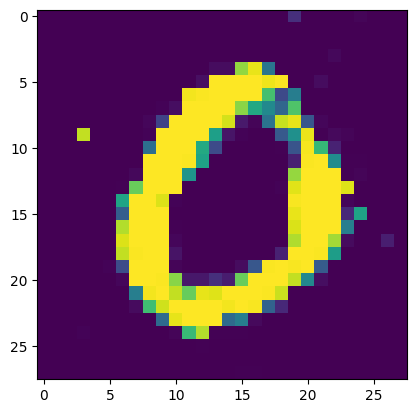

discr guess: 0.5729040503501892

Epoch #45
generator loss: 0.5840141773223877
discriminator loss: 1.0756688714027405


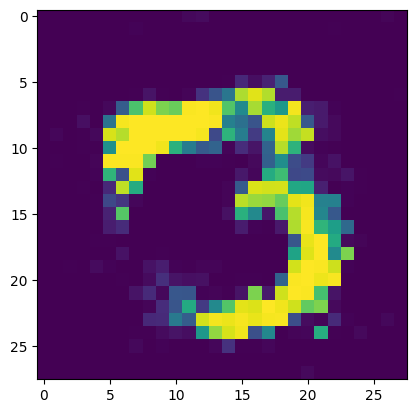

discr guess: 0.38849616050720215

Epoch #46
generator loss: 0.6126949787139893
discriminator loss: 1.1526569724082947


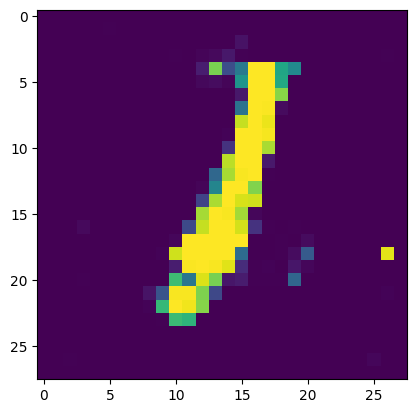

discr guess: 0.6837947964668274

Epoch #47
generator loss: 0.5200852751731873
discriminator loss: 1.077239841222763


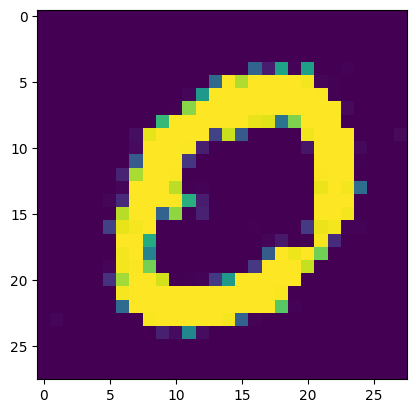

discr guess: 0.5837385058403015

Epoch #48
generator loss: 0.4967714250087738
discriminator loss: 1.2798301577568054


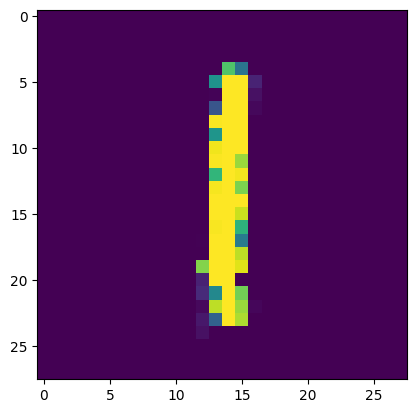

discr guess: 0.7281818985939026

Epoch #49
generator loss: 0.5578292012214661
discriminator loss: 1.2516895979642868


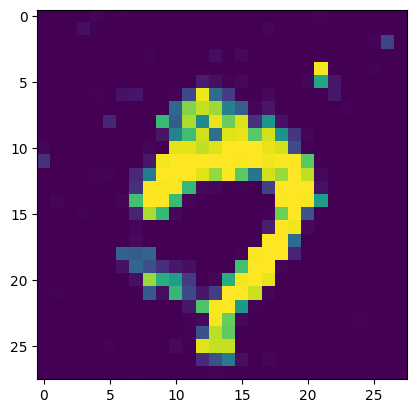

discr guess: 0.38682228326797485


In [9]:
# sample GEN_NOISE_DIM numbers from normal distribution with mean=0 variance=1 for num_imgs "samples"
gen_noise = lambda num_imgs=1: torch.randn(num_imgs, GEN_NOISE_DIM)

trainloader = get_train_loader()

loss_fn = nn.BCELoss()

generator = Generator()
discriminator = Discriminator()

OPTIM_LR = 0.0002
OPTIM_BETAS = (0.5, 0.999)
gen_optim = torch.optim.AdamW(generator.parameters(), lr=OPTIM_LR, betas=OPTIM_BETAS)
discr_optim = torch.optim.AdamW(discriminator.parameters(), lr=OPTIM_LR, betas=OPTIM_BETAS)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

discr_losses = []
generator_losses = []
for epoch in range(NUM_EPOCHS):
    for batch_idx, batch in enumerate(trainloader, start=0): # items of [128x28x28, 1] where 1 is the label
        # prep
        batch_imgs = batch[0].flatten(1) # 128x1x28x28 -> 128x784
        batch_size = batch[0].size(0) # perhaps not equal to batch size (128)
        batch_labels = torch.full((batch_size, 1), REAL_LABEL) # 128x1 where 1 is the label (real/fake)
        
        # discriminator on REAL images 
        batch_preds = discriminator(batch_imgs)
        loss_discriminator_real = loss_fn(batch_preds, batch_labels)
        loss_discriminator_real.backward(retain_graph=True)

        # discriminator on FAKE images
        noise = gen_noise(batch_size) # 128x50 with GEN_NOISE_DIM=50
        fake_imgs = generator(noise)
        batch_labels.fill_(FAKE_LABEL)
        
        batch_preds = discriminator(fake_imgs.detach())
        loss_discriminator_fake = loss_fn(batch_preds, batch_labels)
        loss_discriminator_fake.backward()
        
        # update discriminator weights
        discr_optim.step()
        discriminator.zero_grad()
        
        # update generator
        batch_labels.fill_(REAL_LABEL)
        batch_preds_gen = discriminator(fake_imgs)
        loss_generator = loss_fn(batch_preds_gen, batch_labels) # huh? fake imgs in discriminator with real labels?
        loss_generator.backward()
        
        gen_optim.step()
        generator.zero_grad()
        # so essentially this is taking those fake images
        # and feeding them through the (now trained) discriminator
        # and the loss is the difference between discriminator prediction and REAL_LABEL
        # i.e. if discriminator predicted the image as real, then loss is 0
        
    discr_losses.append(loss_discriminator_fake.item() + loss_discriminator_real.item())
    generator_losses.append(loss_generator.item())
        
    if epoch % 10 or epoch == 0:
        print(f"\nEpoch #{epoch}")
        print(f"generator loss: {generator_losses[-1]}")
        print(f"discriminator loss: {discr_losses[-1]}")
        plt.imshow(fake_imgs[0].reshape((28, 28)).detach().numpy())
        plt.show()
        print(f"discr guess: {batch_preds[0].item()}")

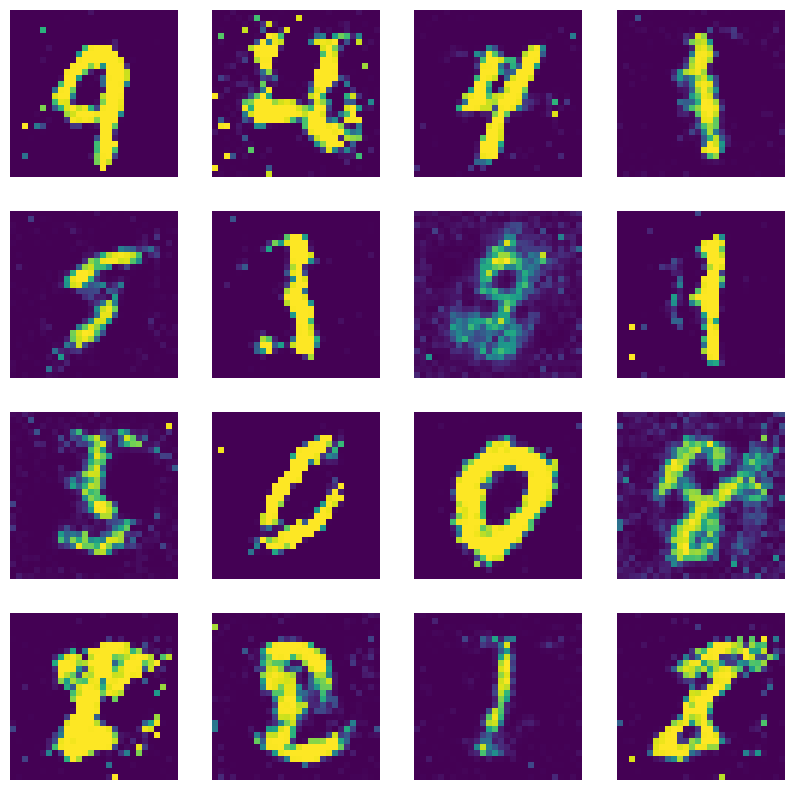

In [21]:
generator.eval()
NUM_TEST_IMGS = 16
test = generator(gen_noise(NUM_TEST_IMGS)).detach()
test = test.reshape((test.size(0), 28, 28))

plt.figure(figsize=(10, 10))
for i in range(NUM_TEST_IMGS):
    plt.subplot(4, 4, i+1)
    plt.imshow(test[i].numpy())
    plt.axis('off')
plt.show()

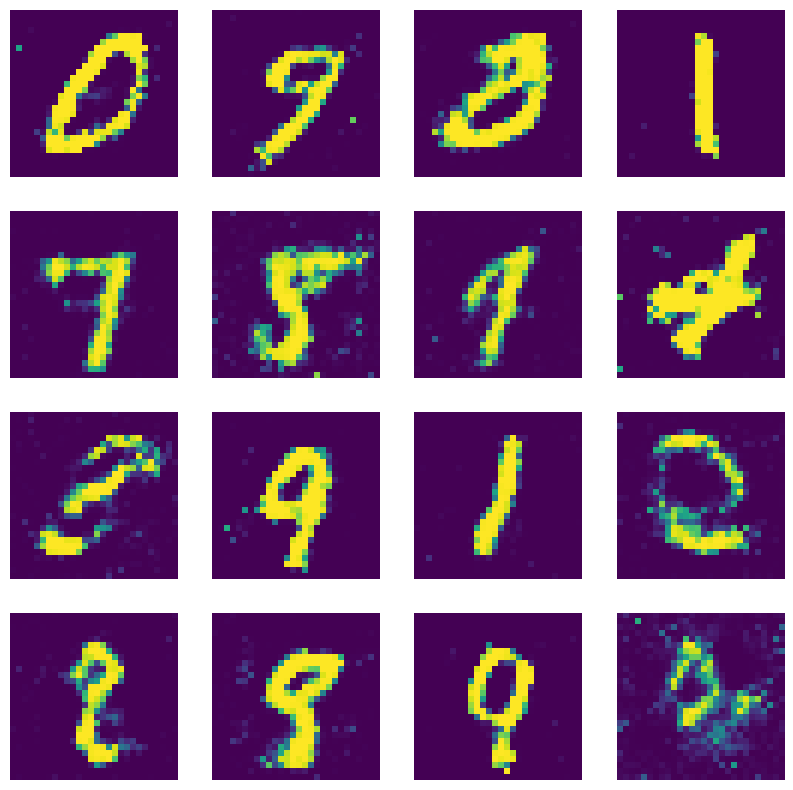

In [22]:
generator.eval()
NUM_TEST_IMGS = 16
test = generator(gen_noise(NUM_TEST_IMGS)).detach()
test = test.reshape((test.size(0), 28, 28))

plt.figure(figsize=(10, 10))
for i in range(NUM_TEST_IMGS):
    plt.subplot(4, 4, i+1)
    plt.imshow(test[i].numpy())
    plt.axis('off')
plt.show()